# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model, metrics, model_selection
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet


## Exploratory Data Analysis 

In [158]:
df_pyme = pd.read_csv("data/Advertising.csv", sep=",")
df_pyme

,Unnamed: 0,TV,radio,newpaper,sales
0,0,230.1,37.8,6s9.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0
...,...,...,...,...,...
195,195,38.2,3.7,13.8,7600.0
196,196,94.2,4.9,8.1,9700.0
197,197,177.0,9.3,6.4,12800.0
198,198,283.6,42.0,66.2,25500.0


In [159]:
df_pyme = df_pyme.drop(df_pyme.columns[0], axis = 1)
df_pyme

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [160]:
df_pyme.loc[0, "newpaper"] = df_pyme.loc[0, "newpaper"].replace("s", "")

In [161]:
df_pyme

,TV,radio,newpaper,sales
0,230.1,37.8,69.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0
...,...,...,...,...
195,38.2,3.7,13.8,7600.0
196,94.2,4.9,8.1,9700.0
197,177.0,9.3,6.4,12800.0
198,283.6,42.0,66.2,25500.0


In [162]:
df_pyme["newpaper"] = df_pyme["newpaper"].apply(pd.to_numeric, errors='coerce')
df_pyme.head()

,TV,radio,newpaper,sales
0,230.1,37.8,69.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


In [163]:
df_pyme.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TV        200 non-null    float64
 1   radio     200 non-null    float64
 2   newpaper  200 non-null    float64
 3   sales     200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [164]:
df_pyme.isnull().sum()

TV          0
radio       0
newpaper    0
sales       0
dtype: int64

In [165]:
df_pyme.describe()

,TV,radio,newpaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14022.500000
std,85.854236,14.846809,21.778621,5217.456566
min,0.700000,0.000000,0.300000,1600.000000
25%,74.375000,9.975000,12.750000,10375.000000
50%,149.750000,22.900000,25.750000,12900.000000
75%,218.825000,36.525000,45.100000,17400.000000
max,296.400000,49.600000,114.000000,27000.000000


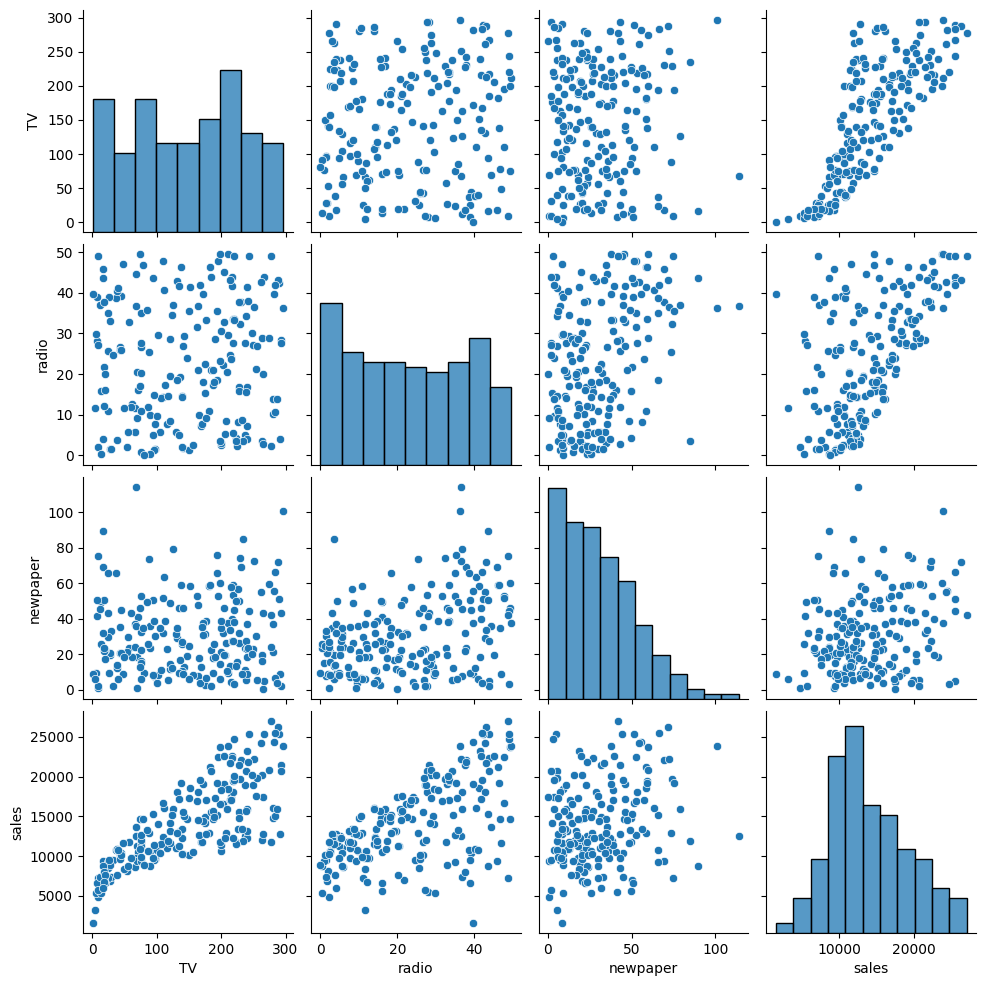

In [166]:
sns.pairplot(df_pyme)

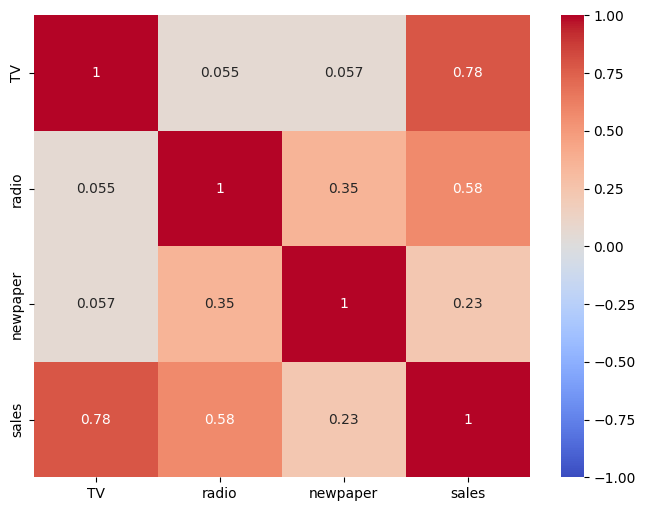

In [167]:
plt.figure(figsize=(8,6))
sns.heatmap(df_pyme.corr(), annot=True, vmin=-1, cmap='coolwarm');
plt.show();

## Modelado

### Modelo de regresión lineal con todas las features

In [168]:
X = df_pyme.iloc[:,:-1]
X

,TV,radio,newpaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [169]:
y = df_pyme.iloc[:,-1]
y

0      22100.0
1      10400.0
2       9300.0
3      18500.0
4      12900.0
        ...   
195     7600.0
196     9700.0
197    12800.0
198    25500.0
199    13400.0
Name: sales, Length: 200, dtype: float64

In [170]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(160, 3)
(160,)
(40, 3)
(40,)


In [171]:
pyme_model = LinearRegression()
pyme_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [172]:
print("___________TRAIN___________")
pred_train = pyme_model.predict(X_train)
print("MAE: ", metrics.mean_absolute_error(y_train, pred_train))
print("RMSE: ", metrics.root_mean_squared_error(y_train, pred_train))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_train, pred_train))
print("R2: ", metrics.r2_score(y_train, pred_train))
print("___________TEST___________")
pred = pyme_model.predict(X_test)
print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

___________TRAIN___________
MAE:  1155.0708474274566
RMSE:  1504.5161501803843
MAPE:  0.10852745100610457
R2:  0.9111583949248847
___________TEST___________
MAE:  1610.6841101464008
RMSE:  2275.4954659311825
MAPE:  0.26969730492520483
R2:  0.8449174816183895


El modelo lineal predice bastante bien, explicando el 84.5% de la variabilidad de las ventas (R² = 0.845).

En promedio, las predicciones se desvían unas 1,600 unidades de ventas (MAE = 1610.7), y los errores más grandes alcanzan alrededor de 2275 unidades (RMSE = 2275.5).

El error porcentual medio es de 27% (MAPE = 0.27), lo que indica un desempeño moderado, razonable para un modelo lineal, pero con margen de mejora. Las predicciones se desvian un 27% respecto a los valores reales de ventas

El MAE, RMSE y MAPE indican errores moderados pero esperables para un modelo lineal con estas variables.

El R² alto muestra que, a pesar de los errores, el modelo captura bien la tendencia general de las ventas. R² = 0.845, indica que solo se explicaba el 84.5% de la variación de las ventas; hay un 15.5% de variación que el modelo no puede capturar.

Text(0, 0.5, 'predicciones')

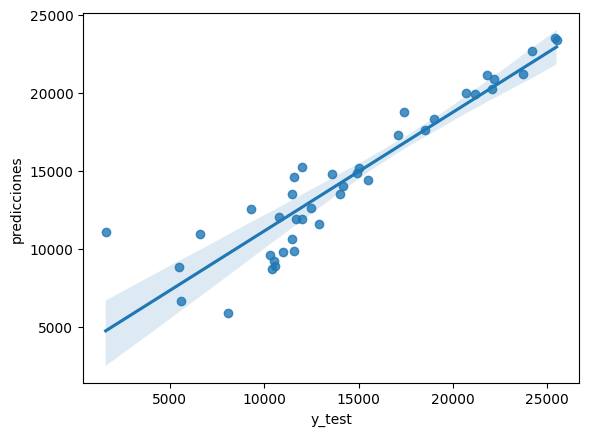

In [174]:
sns.regplot(data = df_pyme, x= y_test, y= pred)
plt.xlabel("y_test")
plt.ylabel("predicciones")

In [ ]:
valores = X_test.copy() 
valores["Ventas"] = y_test
valores["Predicciones"] = pred
valores

In [ ]:
valores_final = valores[["Ventas", "Predicciones"]]
valores_final

### Preprocesamiento polinómico del modelo de regresión lienal anterior

In [181]:
reg_pol = PolynomialFeatures(degree=2)
reg_pol.fit(X_train)

,degree,2
,interaction_only,False
,include_bias,True
,order,'C'


In [182]:
X_train_poly = reg_pol.transform(X_train)
X_test_poly = reg_pol.transform(X_test)

In [183]:
pyme_model_poly = LinearRegression()
pyme_model_poly.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [184]:
print("___________TRAIN___________")
pred_poly_train = pyme_model_poly.predict(X_train_poly)
print("MAE: ", metrics.mean_absolute_error(y_train, pred_poly_train))
print("RMSE: ", metrics.root_mean_squared_error(y_train, pred_poly_train))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_train, pred_poly_train))
print("R2: ", metrics.r2_score(y_train, pred_poly_train))

print("___________TEST___________")
pred_poly = pyme_model_poly.predict(X_test_poly)
print("MAE: ", metrics.mean_absolute_error(y_test, pred_poly))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_poly))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_poly))
print("R2: ", metrics.r2_score(y_test, pred_poly))

___________TRAIN___________
MAE:  359.4524603809552
RMSE:  485.7098237781873
MAPE:  0.036571072862252293
R2:  0.9907407360816549
___________TEST___________
MAE:  568.9039871348534
RMSE:  1004.8169313475114
MAPE:  0.12451201058635346
R2:  0.969759791256035


#### CONCLUSIONES

- El error promedio (MAE) se reduce drásticamente, pasando de 1610 a 569.
- Los errores grandes (RMSE) disminuyen mucho, lo que indica mejor ajuste incluso para predicciones extremas.
- El error porcentual promedio (MAPE) se reduce a menos de la mitad, mostrando predicciones más precisas en términos relativos.
- Ahora el modelo explica el 97% de la variabilidad de las ventas, mucho mejor que antes (R2). Casi toda la variación en las ventas se explica por las features.

## NORMALIZACIÓN - REGULARIZACIÓN

#### NORMALIZACIÓN

In [202]:
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal  = scaler.transform(X_test)

In [203]:
pyme_model_scal = LinearRegression()
pyme_model_scal.fit(X_train_scal, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [204]:
pred_scal = pyme_model_scal.predict(X_test_scal)
baseline_error = metrics.mean_squared_error(y_test, pred_scal)

print("___________TEST___________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_scal))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_scal))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_scal))
print("R2: ", metrics.r2_score(y_test, pred_scal))

___________TEST___________
MAE:  1610.6841101464008
RMSE:  2275.495465931182
MAPE:  0.2696973049252048
R2:  0.8449174816183896


EL MODELO DE REGRESIÓN LINEAL CON LOS DATOS NORAMILIZADOS DA LAS MISMAS MÉTRICAS QUE CON LOS DATOS SIN NORMALIZAR.

#### REGULARIZACIÓN: Ridge regression 

In [197]:
ridgeR = Ridge(alpha = 40)
ridgeR.fit(X_train_scal, y_train)

print("Train MAE sin regularización: ", round(metrics.mean_absolute_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test MAE sin regularización: ", round(metrics.mean_absolute_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train MSE sin regularización: ", round(metrics.mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)),2))
print("Test MSE sin regularización: ", round(metrics.mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)),2))
print("Train RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train R2 sin regularización: ", metrics.r2_score(y_train, pyme_model_scal.predict(X_train_scal)))
print("Test R2 sin regularización: ", metrics.r2_score(y_test, pyme_model_scal.predict(X_test_scal)))
print("____________________________________________________________________")
print("Train MAE con regularización: ", round(metrics.mean_absolute_error(y_train, ridgeR.predict(X_train_scal)), 2))
print("Test MAE con regularización: ", round(metrics.mean_absolute_error(y_test, ridgeR.predict(X_test_scal)), 2))
print("Train MSE con regularización: ", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train_scal)),2))
print("Test MSE con regularización: ", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test_scal)),2))
print("Train RMSE con regularización: ", round(metrics.root_mean_squared_error(y_train, ridgeR.predict(X_train_scal)), 2))
print("Test RMSE con regularización: ", round(metrics.root_mean_squared_error(y_test, ridgeR.predict(X_test_scal)), 2))
print("Train R2 con regularización: ", metrics.r2_score(y_train, ridgeR.predict(X_train_scal)))
print("Test R2 con regularización: ", metrics.r2_score(y_test, ridgeR.predict(X_test_scal)))

"""
print("Train MSE con regularización:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train_scal)),2))
print("Test MSE con regularización:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test_scal)),2))
# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))))
"""

Train MAE sin regularización:  1155.07
Test MAE sin regularización:  1610.68
Train MSE sin regularización:  2263568.85
Test MSE sin regularización:  5177879.62
Train RMSE sin regularización:  1504.52
Test RMSE sin regularización:  2275.5
Train R2 sin regularización:  0.9111583949248847
Test R2 sin regularización:  0.8449174816183896
____________________________________________________________________
Train MAE con regularización:  1329.04
Test MAE con regularización:  1855.24
Train MSE con regularización:  3152300.97
Test MSE con regularización:  6955416.03
Train RMSE con regularización:  1775.47
Test RMSE con regularización:  2637.31
Train R2 con regularización:  0.8762770223234472
Test R2 con regularización:  0.7916785412220642


'\nprint("Train MSE con regularización:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train_scal)),2))\nprint("Test MSE con regularización:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test_scal)),2))\n# print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))))\n'

EMPEORAN LAS MÉTRICAS CON ALPHA = 40

In [205]:
n_alphas = 100
# CREA ARRAY, -4 y 3 son las potencias de la escala logaritmica
alphas = np.logspace(-4, 3, n_alphas) 
print(np.min(alphas))
print(np.max(alphas))

0.0001
1000.0


In [233]:
n_alphas = 100
# CREA ARRAY, -4 y 3 son las potencias de la escala logaritmica
alphas = np.logspace(-4, 9, n_alphas) 

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scal, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test_scal)
    ridge_error = metrics.mean_squared_error(y_test, y_pred)
    
    err_ridge.append(ridge_error)
    baseline.append(baseline_error)

In [238]:
min(err_ridge)

5177881.867307964

In [239]:
np.array(err_ridge).argmin()

np.int64(0)

In [240]:
alphas[np.array(err_ridge).argmin()]

np.float64(0.0001)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\2259414854.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=20)


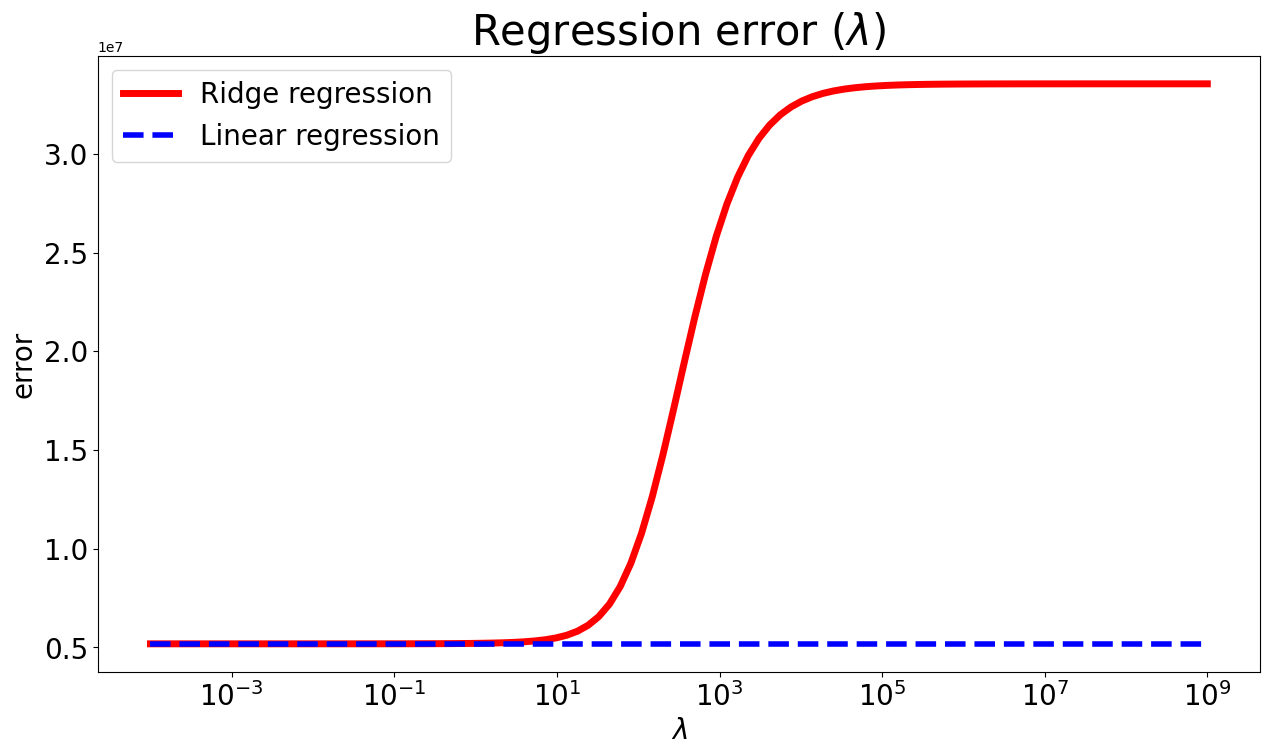

In [ ]:
plt.figure(figsize=(15,8))
ax = plt.gca()
ax.plot(alphas, err_ridge, linewidth=5, color='red', label="Ridge regression")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('error', fontsize=20)
ax.legend(fontsize=20)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show();

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\2393052791.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


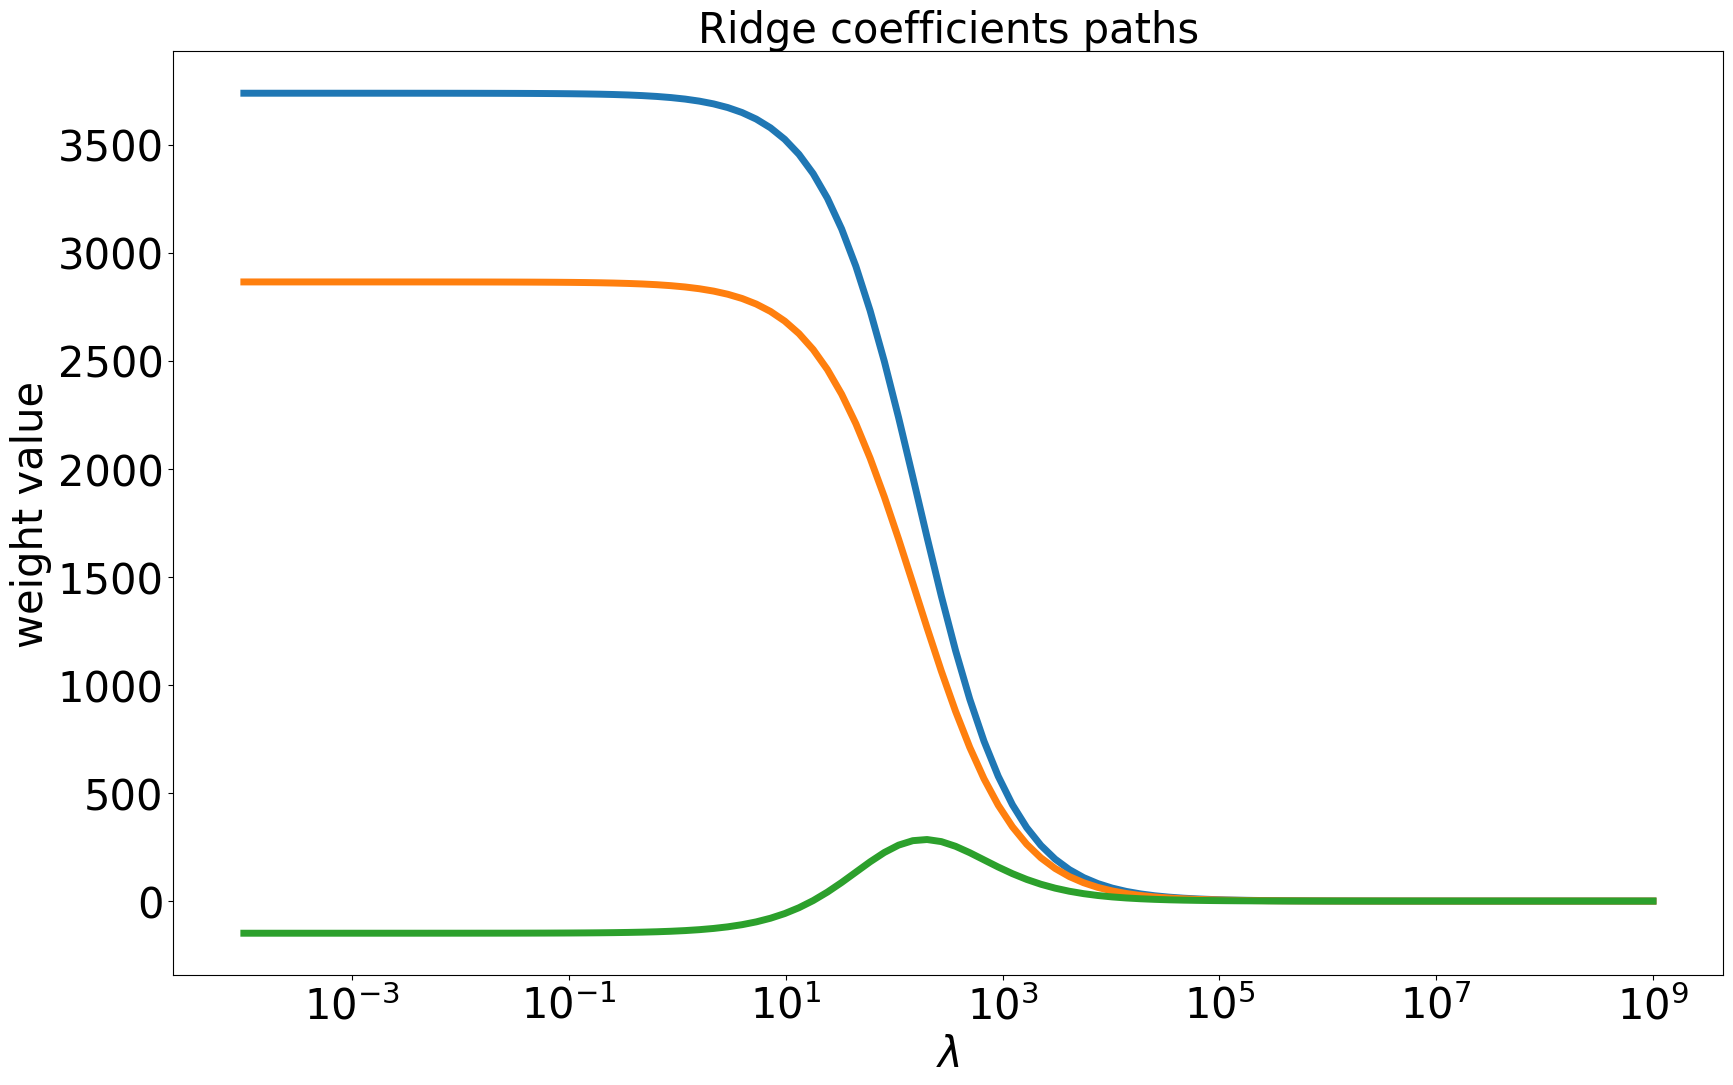

In [237]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, coef_ridge, linewidth=5)
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('weight value', fontsize=30)
plt.title('Ridge coefficients paths', fontsize=30)
plt.show()

In [271]:
ridgeR = Ridge(alpha = 0.1)
ridgeR.fit(X_train_scal, y_train)

print("Train MAE sin regularización: ", round(metrics.mean_absolute_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test MAE sin regularización: ", round(metrics.mean_absolute_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train MSE sin regularización: ", round(metrics.mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)),2))
print("Test MSE sin regularización: ", round(metrics.mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)),2))
print("Train RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train R2 sin regularización: ", metrics.r2_score(y_train, pyme_model_scal.predict(X_train_scal)))
print("Test R2 sin regularización: ", metrics.r2_score(y_test, pyme_model_scal.predict(X_test_scal)))
print("____________________________________________________________________")
print("Train MAE con regularización: ", round(metrics.mean_absolute_error(y_train, ridgeR.predict(X_train_scal)), 2))
print("Test MAE con regularización: ", round(metrics.mean_absolute_error(y_test, ridgeR.predict(X_test_scal)), 2))
print("Train MSE con regularización: ", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train_scal)),2))
print("Test MSE con regularización: ", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test_scal)),2))
print("Train RMSE con regularización: ", round(metrics.root_mean_squared_error(y_train, ridgeR.predict(X_train_scal)), 2))
print("Test RMSE con regularización: ", round(metrics.root_mean_squared_error(y_test, ridgeR.predict(X_test_scal)), 2))
print("Train R2 con regularización: ", metrics.r2_score(y_train, ridgeR.predict(X_train_scal)))
print("Test R2 con regularización: ", metrics.r2_score(y_test, ridgeR.predict(X_test_scal)))

Train MAE sin regularización:  1155.07
Test MAE sin regularización:  1610.68
Train MSE sin regularización:  2263568.85
Test MSE sin regularización:  5177879.62
Train RMSE sin regularización:  1504.52
Test RMSE sin regularización:  2275.5
Train R2 sin regularización:  0.9111583949248847
Test R2 sin regularización:  0.8449174816183896
____________________________________________________________________
Train MAE con regularización:  1155.13
Test MAE con regularización:  1611.27
Train MSE con regularización:  2263577.93
Test MSE con regularización:  5180141.23
Train RMSE con regularización:  1504.52
Test RMSE con regularización:  2275.99
Train R2 con regularización:  0.9111580382309198
Test R2 con regularización:  0.8448497440563059


#### REGULARIZACIÓN: LASSO

In [295]:
lassoR = Lasso(alpha=0.1)
lassoR.fit(X_train_scal, y_train)

print("Train MAE sin regularización: ", round(metrics.mean_absolute_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test MAE sin regularización: ", round(metrics.mean_absolute_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train MSE sin regularización: ", round(metrics.mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)),2))
print("Test MSE sin regularización: ", round(metrics.mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)),2))
print("Train RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train R2 sin regularización: ", metrics.r2_score(y_train, pyme_model_scal.predict(X_train_scal)))
print("Test R2 sin regularización: ", metrics.r2_score(y_test, pyme_model_scal.predict(X_test_scal)))
print("____________________________________________________________________")
print("Train MAE con regularización: ", round(metrics.mean_absolute_error(y_train, lassoR.predict(X_train_scal)), 2))
print("Test MAE con regularización: ", round(metrics.mean_absolute_error(y_test, lassoR.predict(X_test_scal)), 2))
print("Train MSE con regularización: ", round(metrics.mean_squared_error(y_train, lassoR.predict(X_train_scal)),2))
print("Test MSE con regularización: ", round(metrics.mean_squared_error(y_test, lassoR.predict(X_test_scal)),2))
print("Train RMSE con regularización: ", round(metrics.root_mean_squared_error(y_train, lassoR.predict(X_train_scal)), 2))
print("Test RMSE con regularización: ", round(metrics.root_mean_squared_error(y_test, lassoR.predict(X_test_scal)), 2))
print("Train R2 con regularización: ", metrics.r2_score(y_train, lassoR.predict(X_train_scal)))
print("Test R2 con regularización: ", metrics.r2_score(y_test, lassoR.predict(X_test_scal)))

Train MAE sin regularización:  1155.07
Test MAE sin regularización:  1610.68
Train MSE sin regularización:  2263568.85
Test MSE sin regularización:  5177879.62
Train RMSE sin regularización:  1504.52
Test RMSE sin regularización:  2275.5
Train R2 sin regularización:  0.9111583949248847
Test R2 sin regularización:  0.8449174816183896
____________________________________________________________________
Train MAE con regularización:  1155.07
Test MAE con regularización:  1610.7
Train MSE con regularización:  2263568.89
Test MSE con regularización:  5177828.89
Train RMSE con regularización:  1504.52
Test RMSE con regularización:  2275.48
Train R2 con regularización:  0.9111583933308952
Test R2 con regularización:  0.8449190007717167


In [284]:
lasso = linear_model.Lasso(fit_intercept=False)

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = metrics.mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\622328189.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


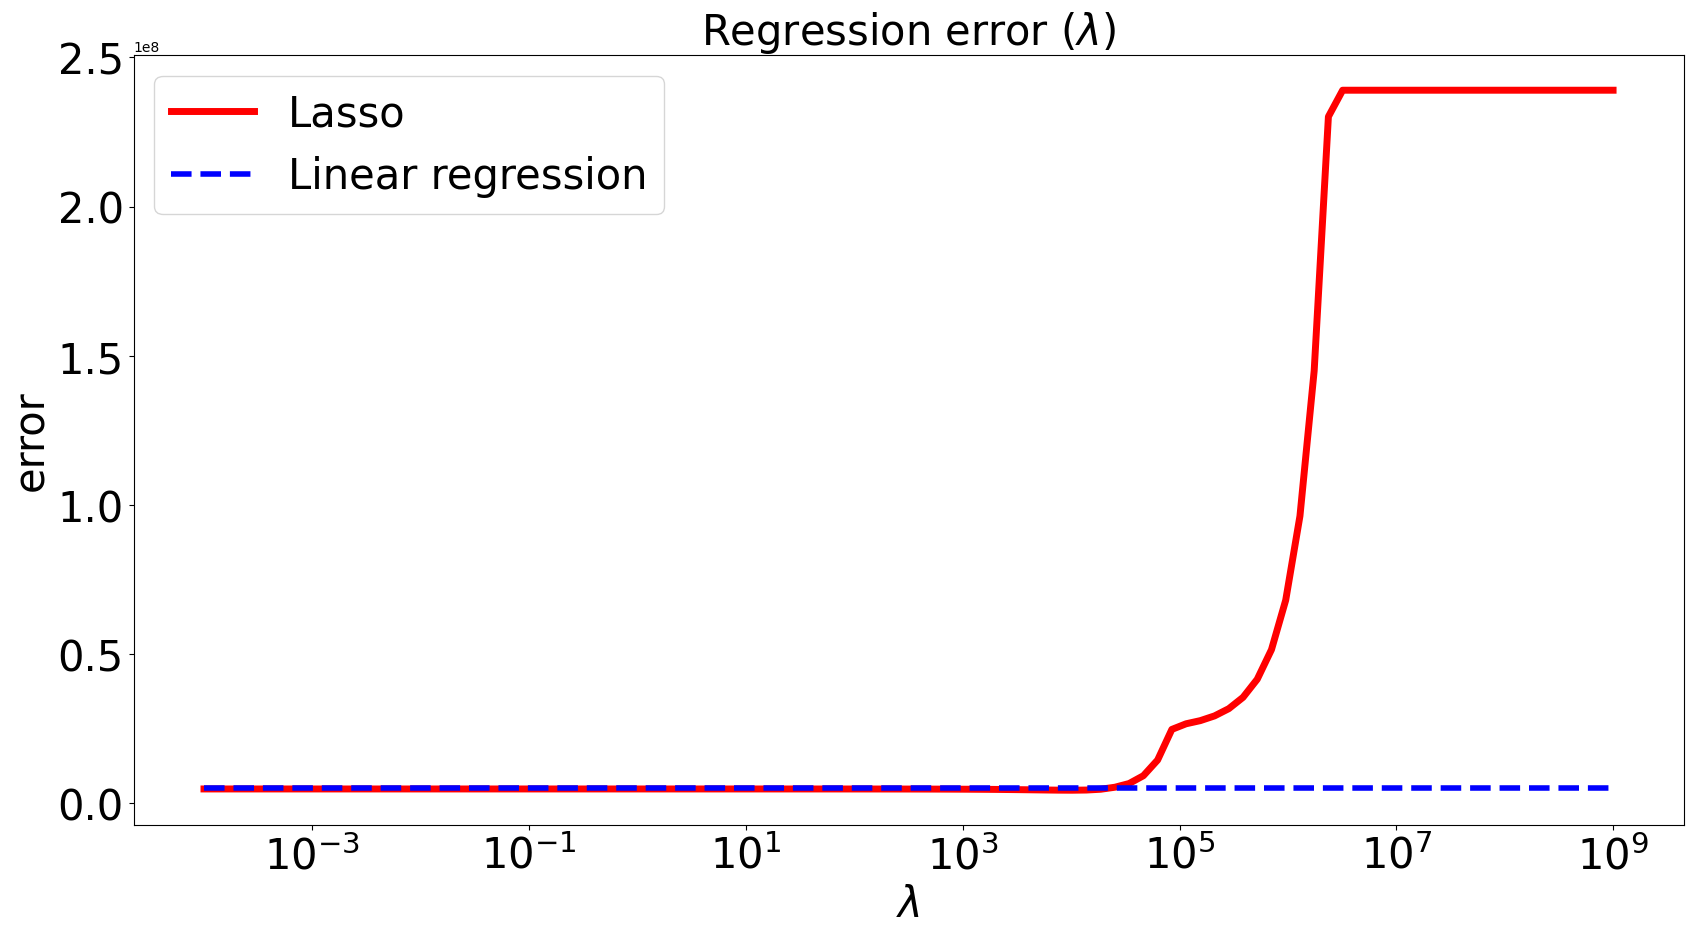

In [285]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_lasso, linewidth=5, color='red', label="Lasso")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\lambda$)', fontsize=30)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\2245268358.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


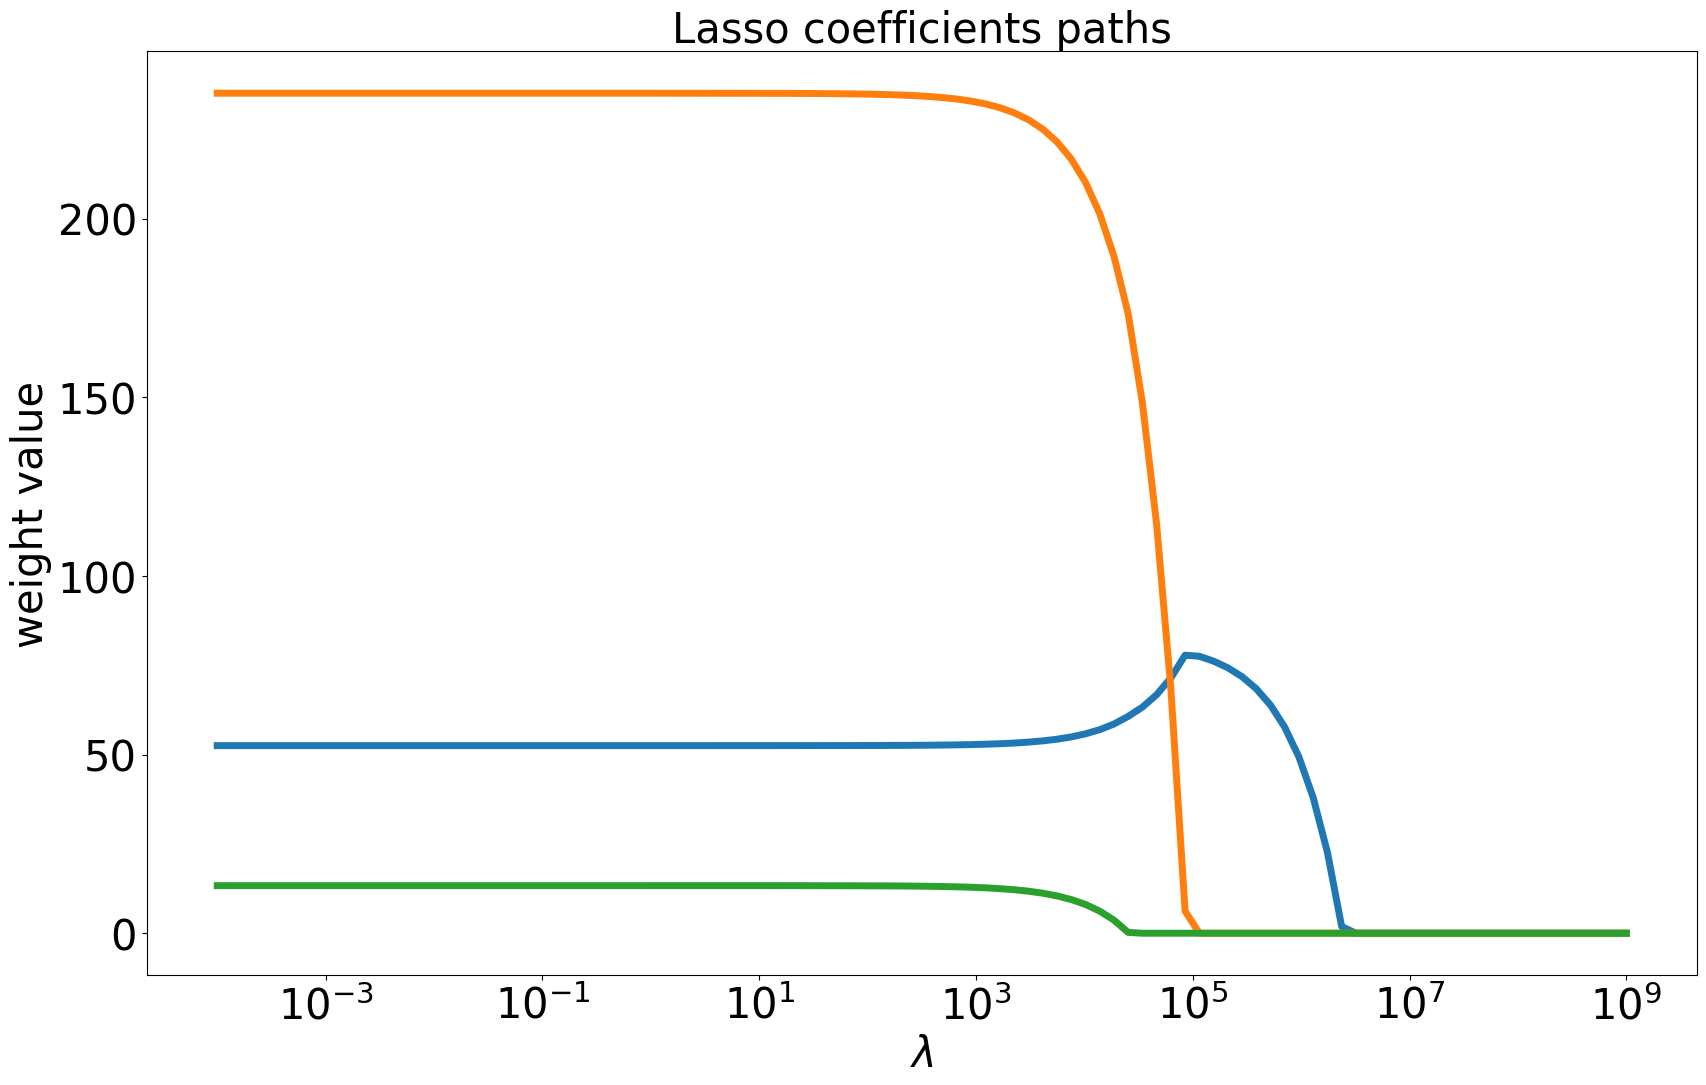

In [287]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, coef_lasso, linewidth=5)
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('weight value', fontsize=30)
plt.title('Lasso coefficients paths', fontsize=30)
plt.show()

#### REGULARIZACIÓN: ELASTIC NET    

In [300]:
elastic_net = ElasticNet(alpha = 0.0001, l1_ratio = 0.5)
elastic_net.fit(X_train_scal, y_train)

print("Train MAE sin regularización: ", round(metrics.mean_absolute_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test MAE sin regularización: ", round(metrics.mean_absolute_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train MSE sin regularización: ", round(metrics.mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)),2))
print("Test MSE sin regularización: ", round(metrics.mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)),2))
print("Train RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_train, pyme_model_scal.predict(X_train_scal)), 2))
print("Test RMSE sin regularización: ", round(metrics.root_mean_squared_error(y_test, pyme_model_scal.predict(X_test_scal)), 2))
print("Train R2 sin regularización: ", metrics.r2_score(y_train, pyme_model_scal.predict(X_train_scal)))
print("Test R2 sin regularización: ", metrics.r2_score(y_test, pyme_model_scal.predict(X_test_scal)))
print("____________________________________________________________________")
print("Train MAE con regularización: ", round(metrics.mean_absolute_error(y_train, elastic_net.predict(X_train_scal)), 2))
print("Test MAE con regularización: ", round(metrics.mean_absolute_error(y_test, elastic_net.predict(X_test_scal)), 2))
print("Train MSE con regularización: ", round(metrics.mean_squared_error(y_train, elastic_net.predict(X_train_scal)),2))
print("Test MSE con regularización: ", round(metrics.mean_squared_error(y_test, elastic_net.predict(X_test_scal)),2))
print("Train RMSE con regularización: ", round(metrics.root_mean_squared_error(y_train, elastic_net.predict(X_train_scal)), 2))
print("Test RMSE con regularización: ", round(metrics.root_mean_squared_error(y_test, elastic_net.predict(X_test_scal)), 2))
print("Train R2 con regularización: ", metrics.r2_score(y_train, elastic_net.predict(X_train_scal)))
print("Test R2 con regularización: ", metrics.r2_score(y_test, elastic_net.predict(X_test_scal)))

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, elastic_net.predict(X_train_scal)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, elastic_net.predict(X_test)))

Train MAE sin regularización:  1155.07
Test MAE sin regularización:  1610.68
Train MSE sin regularización:  2263568.85
Test MSE sin regularización:  5177879.62
Train RMSE sin regularización:  1504.52
Test RMSE sin regularización:  2275.5
Train R2 sin regularización:  0.9111583949248847
Test R2 sin regularización:  0.8449174816183896
____________________________________________________________________
Train MAE con regularización:  1155.08
Test MAE con regularización:  1610.73
Train MSE con regularización:  2263568.9
Test MSE con regularización:  5178059.81
Train RMSE con regularización:  1504.52
Test RMSE con regularización:  2275.54
Train R2 con regularización:  0.9111583926374003
Test R2 con regularización:  0.844912084568028
Train MSE: 2263568.9044
Test MSE: 441106375357.8988


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


In [301]:
coef_eln = []
err_eln = []
baseline = []
for a in alphas:
    # El ratio a 1 es tirando a Lasso
    elastic_net = ElasticNet(alpha = a, l1_ratio=1)
    elastic_net.fit(X_train, y_train)
    coef_eln.append(elastic_net.coef_)
    y_pred = elastic_net.predict(X_test)
    elasticnet_error = metrics.mean_squared_error(y_pred, y_test)
    err_eln.append(elasticnet_error)
    baseline.append(baseline_error)

In [302]:
min(err_eln)

4999357.549811087

<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\1927193226.py:7: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


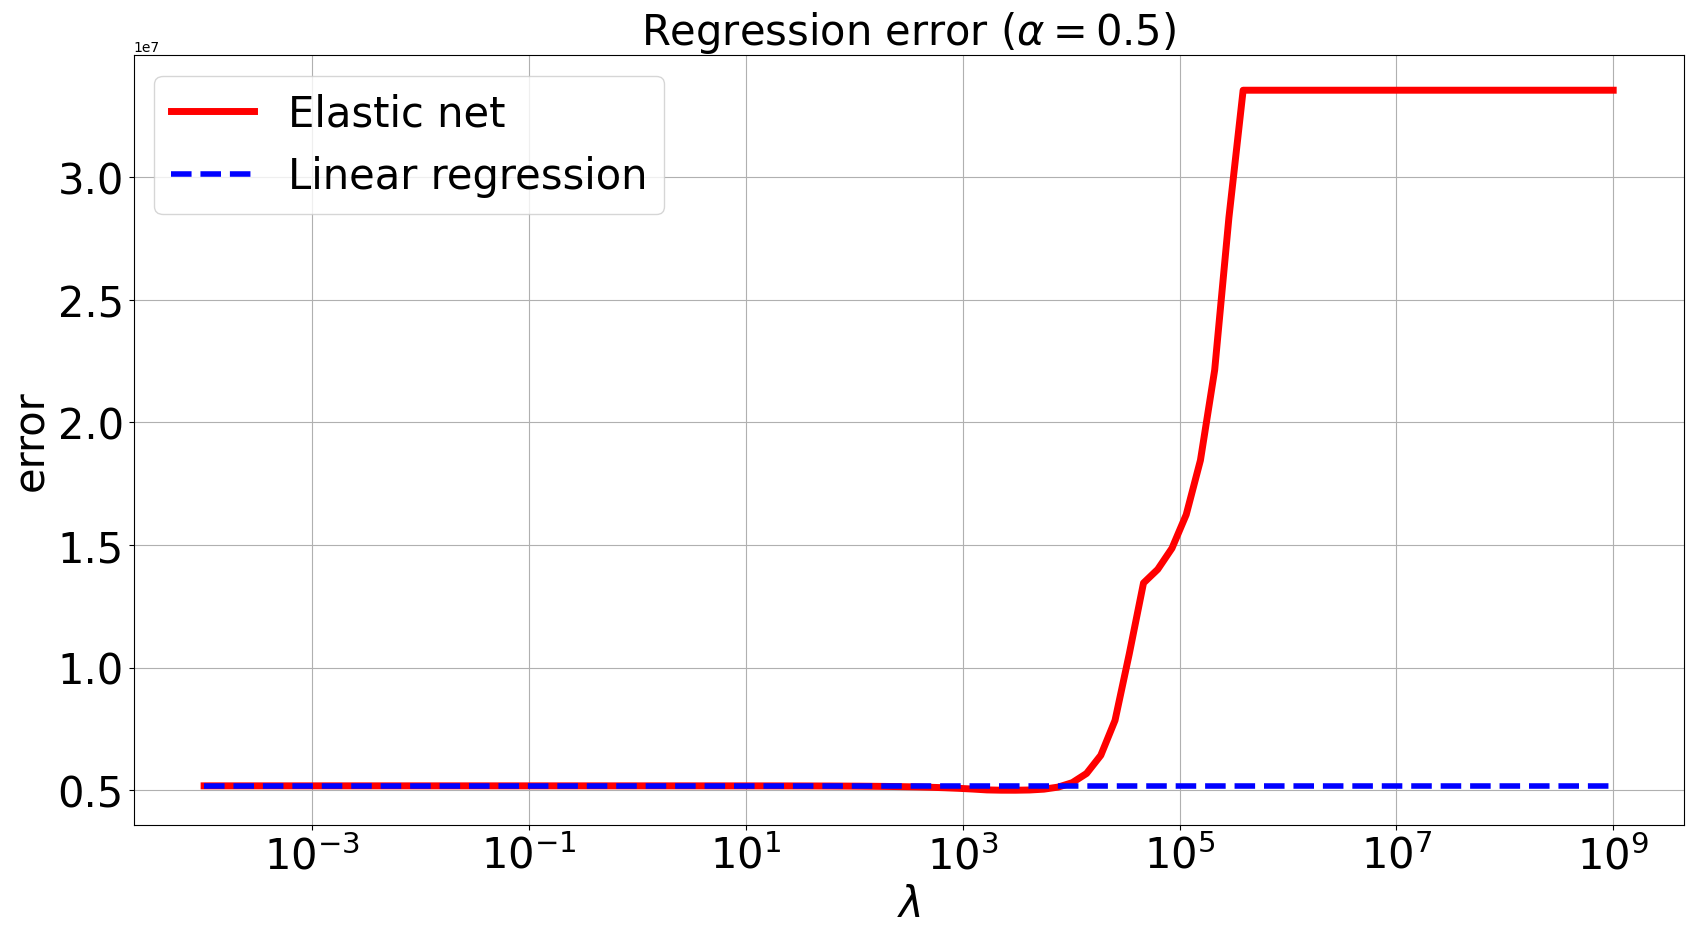

In [303]:
plt.figure(figsize=(20,10))
ax = plt.gca()
ax.plot(alphas, err_eln, linewidth=5, color='red', label="Elastic net")
ax.plot(alphas, baseline, linewidth=4,linestyle='--', color='blue', label='Linear regression')
ax.set_xscale('log')
plt.grid(True)
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('error', fontsize=30)
ax.legend(fontsize=30)
plt.title(r'Regression error ($\alpha=0.5$)', fontsize=30)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Administrador\AppData\Local\Temp\ipykernel_16232\1433961484.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('$\lambda$', fontsize=30)


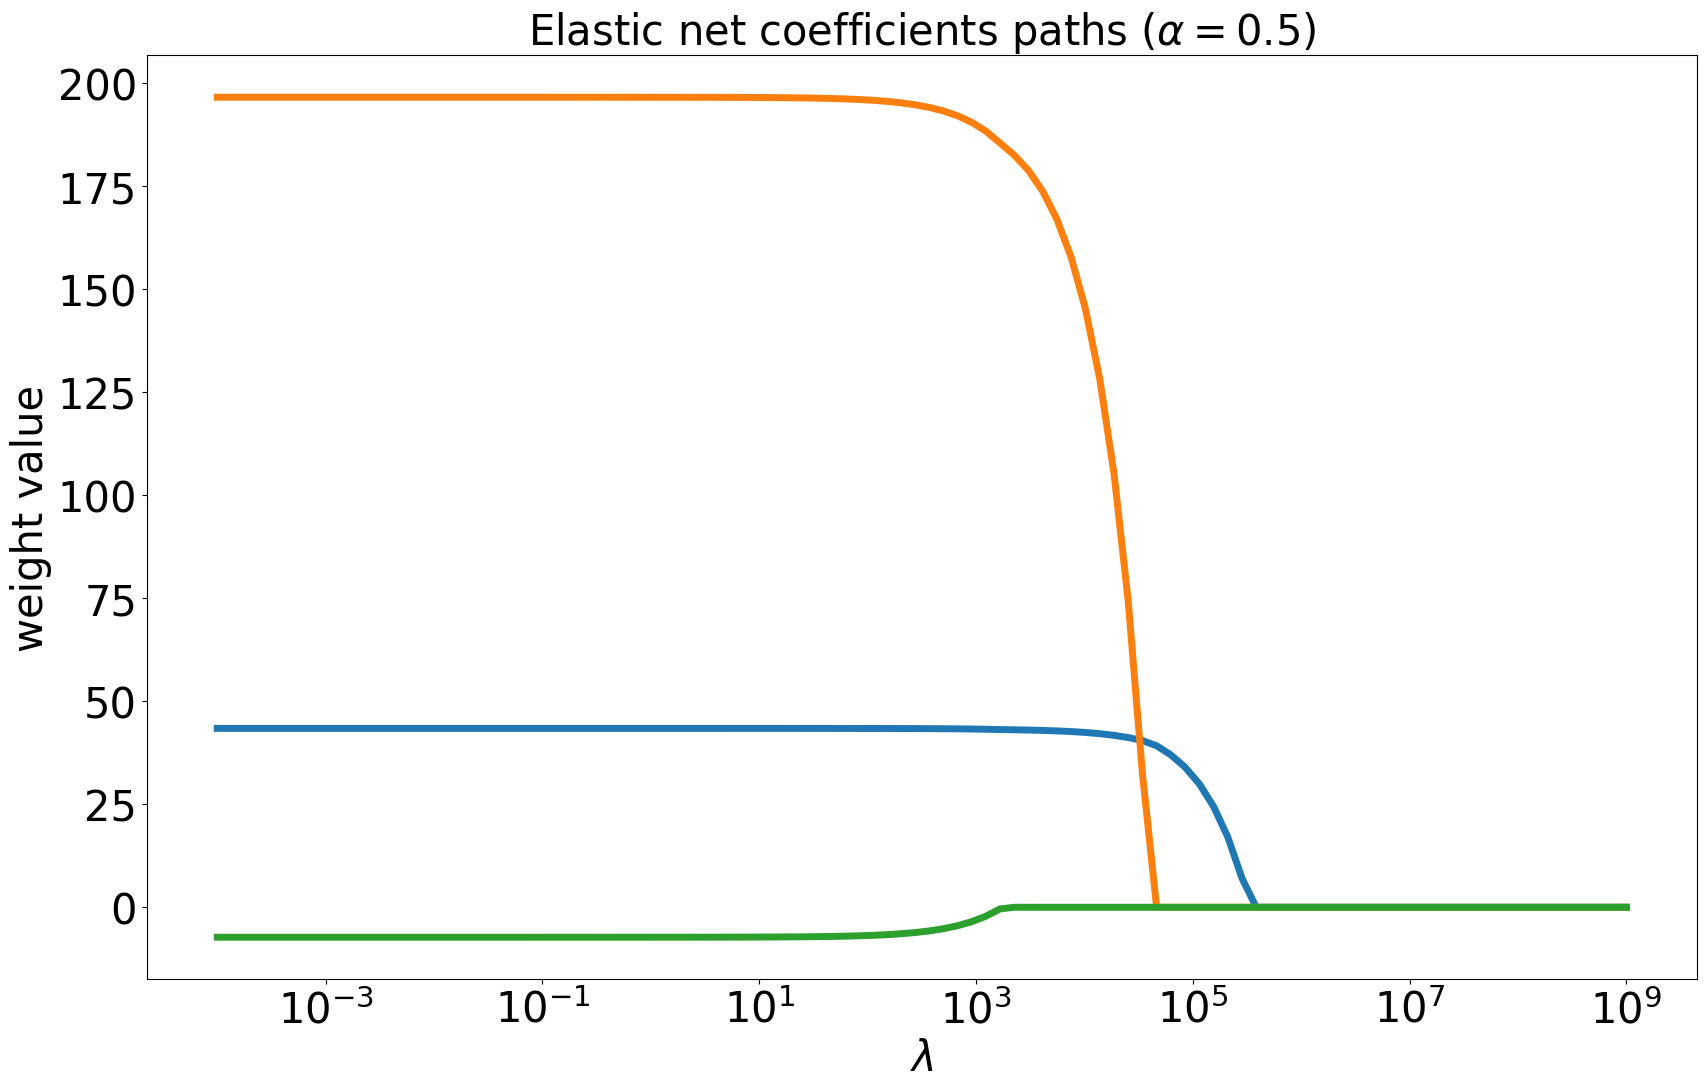

In [304]:
plt.figure(figsize=(20,12))
ax = plt.gca()
ax.plot(alphas, coef_eln, linewidth=5)
ax.set_xscale('log')
plt.xlabel('$\lambda$', fontsize=30)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.ylabel('weight value', fontsize=30)
plt.title(r'Elastic net coefficients paths ($\alpha=0.5$)', fontsize=30)
plt.show()

In [305]:
print("Linear regression error:   %0.4f" % baseline_error)
print("Minimun ridge error:       %0.4f" % min(err_ridge))
print("Minimum lasso error:       %0.4f" % min(err_lasso))
print("Minimum elastic net error: %0.4f" % min(err_eln))

Linear regression error:   5177879.6155
Minimun ridge error:       5177881.8673
Minimum lasso error:       4355238.7055
Minimum elastic net error: 4999357.5498
